<a href="https://colab.research.google.com/github/isaactabor21/ds6050-final-project/blob/main/wildfires.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS 6050 Final Project

**Deep Learning for Satellite-Based Wildfire Detection**

**Convolutional Neural Networks (CNNs) for Wildfire Detection**

**Names with UVA IDs:** Isaac Tabor (zds3st), Michael Dunlap (upw4ys), Jarrett Markman (gzt8na)



The goal of our project is to help address the problem of wildfire detection by building a deep learning model capable of identifying wildfire-affected regions from satellite imagery, by classifying satellite image patches as either wildfire or no wildfire. This is primarily an application result.

According to NASA, extreme wildfire activity has more than doubled worldwide, and has been amplified due to Earth’s warming climate, especially in northern and temperate forests. Satellite data is rich in helping detect and track them, by helping communities and land managers prepare for and respond to fires and understand this growing risk. NASA’s Terra and Aqua satellites detect active wildfires twice each day. In 2023, Canada’s warmest and driest conditions since 1980 stoked extreme fires that lasted for five months. NASA researchers found that these fires released about 640 million metric tons of carbon. Isaac, being from Minnesota, has also experienced many summer days in Minnesota with unhealthy air quality due to Canadian wildfires.

Training a CNN to classify image patches as “fire” or “no fire” could enhance early detection of wildfires, that could be timelier and more scalable for environmental management and disaster response than manually analyzing large volumes of satellite imagery.

We are using the Wildfire Prediction Dataset (Satellite Images) from Kaggle.

Kaggle URL: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset The creator generated these images by extracting satellite imagery using the Map Box API at latitude and longitude coordinates of wildfire events (>0.01 acres burned) from the Canadian government wildfire dataset. All images are colored. Original wildfire records come from the Government of Canada Open

Data Portal URL: https://open.canada.ca/data/en/dataset/9d8f219c-4df0-4481-926f-8a2a532ca003

**Load the data**
1. First, download the zip file from Kaggle

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# CODE TO UNZIP THE FILE
zip_file_path = '/content/drive/MyDrive/archive.zip'
extract_dir = '.' # '.' is current directory

# Try extracting with the `unzip` shell command
!unzip -q {zip_file_path} -d {extract_dir}

Dataset contains satellite images (350px x 350 px) in 2 classes: Wildfire (22710 images) and No wildfire (20140 images). File names are coordinates, so a stretch goal could be to aggregate predicted probabilities and map it. The data was divided into Train (70%), Test (15%), Validation (15%).



This means 3 folders:
  - a test folder
  - a train folder
  - a valid folder

With each folder containing 2 folders:
  - `nowildfire` folder
  - `wildfire` folder

## EDA

**Show that data is 350px x 350 px**

In [ ]:
# Show that data is 350px x 350 px

import os
from PIL import Image

# Define the root path (adjust if your folder is named differently)
base_path = 'train/nowildfire'

# Get the first image file in that directory
sample_image_name = os.listdir(base_path)[0]
sample_path = os.path.join(base_path, sample_image_name)

# Open and check dimensions
with Image.open(sample_path) as img:
    width, height = img.size
    print(f"Image Path: {sample_path}")
    print(f"Dimensions: {width}px x {height}px")

    if width == 350 and height == 350:
        print("✅ Verification Successful: Image is 350x350.")
    else:
        print("❌ Dimensions do not match 350x350.")

Image Path: train/nowildfire/-114.020213,50.95328.jpg
Dimensions: 350px x 350px
✅ Verification Successful: Image is 350x350.


**Show a no wildfire test image:**

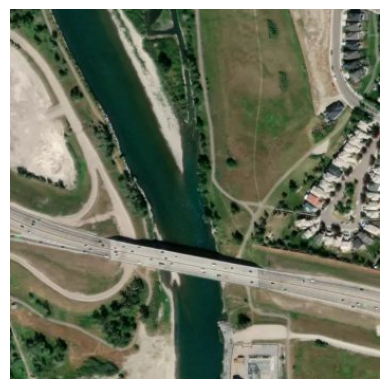

In [ ]:
# Show a no wildfire test image:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Pick one image path from your folder
img_path = 'train/nowildfire/-114.020213,50.95328.jpg'

# Load and show
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off') # This hides the x and y axis numbers
plt.show()

**Show a wildfire test image:**

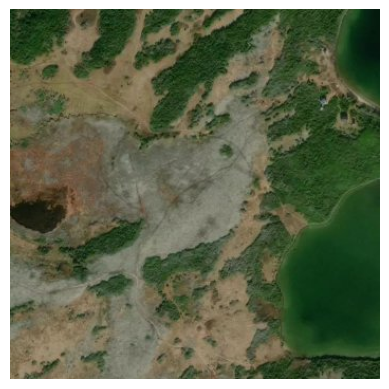

In [ ]:
# Show a no wildfire test image:

# Pick one image path from your folder
img_path = 'train/wildfire/-57.11902,51.47242.jpg'

# Load and show
img = mpimg.imread(img_path)
plt.imshow(img)
plt.axis('off') # This hides the x and y axis numbers
plt.show()

**Show that there are 22710 images that are wildfire**

In [ ]:
# Define the folders to check
splits = ['train', 'test', 'valid']
total_wildfire_count = 0

for split in splits:
    folder_path = os.path.join(split, 'wildfire')

    # Count files in this specific folder
    count = len(os.listdir(folder_path))
    print(f"Wildfire images in {split}: {count}")

    total_wildfire_count += count

print(f"---")
print(f"Total Wildfire Images: {total_wildfire_count}")

if total_wildfire_count == 22710:
    print("✅ The count matches the dataset description!")
else:
    print("❌ The count does not match 22710.")

Wildfire images in train: 15750
Wildfire images in test: 3480
Wildfire images in valid: 3480
---
Total Wildfire Images: 22710
✅ The count matches the dataset description!


**Show that there are 22710 images that are wildfire**

In [ ]:
total_nowildfire_count = 0
for split in splits:
    folder_path = os.path.join(split, 'nowildfire') # SWITCHED THIS TO nowildfire

    # Count files in this specific folder
    count = len(os.listdir(folder_path))
    print(f"No Wildfire images in {split}: {count}")

    total_nowildfire_count += count

print(f"---")
print(f"Total No Wildfire Images: {total_nowildfire_count}")

if total_nowildfire_count == 20140:
    print("✅ The count matches the dataset description!")
else:
    print(f"❌ The count ({total_nowildfire_count}) does not match 20140.")

No Wildfire images in train: 14500
No Wildfire images in test: 2820
No Wildfire images in valid: 2820
---
Total No Wildfire Images: 20140
✅ The count matches the dataset description!


**Show that the data is more or less split into train (70%) test (15%) and validation (15)%**

In [ ]:
split_totals = {}

# Calculate total images (both classes) for each split
for split in splits:
    wildfire_count = len(os.listdir(os.path.join(split, 'wildfire')))
    nowildfire_count = len(os.listdir(os.path.join(split, 'nowildfire')))
    split_totals[split] = wildfire_count + nowildfire_count

grand_total = sum(split_totals.values())

# Print the results and percentages
print(f"Total images in dataset: {grand_total}\n")
for split, total in split_totals.items():
    percentage = (total / grand_total) * 100
    print(f"{split.capitalize()}: {total} images ({percentage:.1f}%)")

Total images in dataset: 42850

Train: 30250 images (70.6%)
Test: 6300 images (14.7%)
Valid: 6300 images (14.7%)


**Show distribution of nowildfire vs wildfire within those splits**

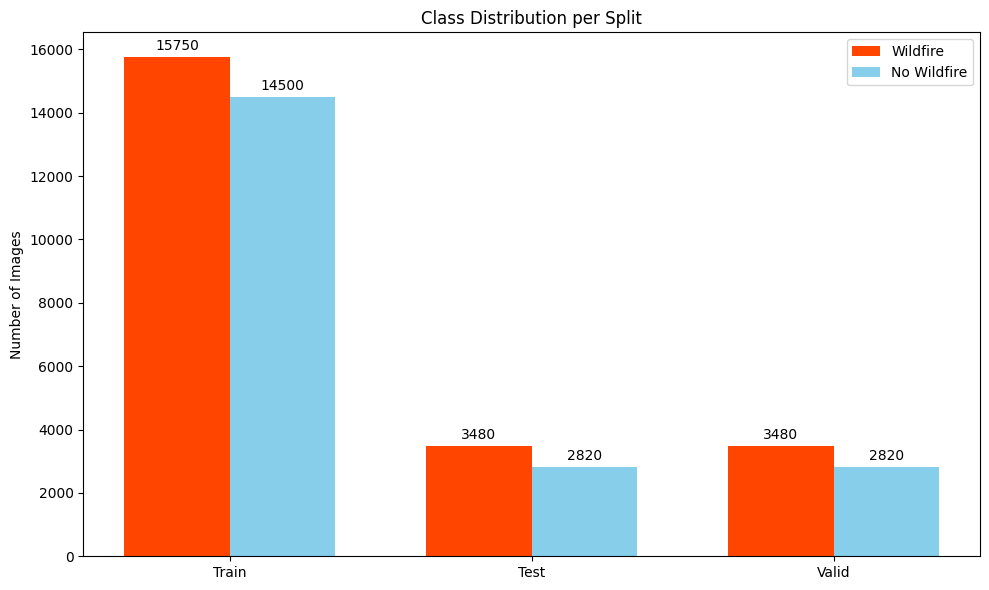

In [ ]:
import numpy as np
wildfire_counts = []
nowildfire_counts = []

# Gather data
for split in splits:
    wildfire_counts.append(len(os.listdir(os.path.join(split, 'wildfire'))))
    nowildfire_counts.append(len(os.listdir(os.path.join(split, 'nowildfire'))))

# Set up the bar chart
x = np.arange(len(splits))  # Label locations
width = 0.35               # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, wildfire_counts, width, label='Wildfire', color='orangered')
rects2 = ax.bar(x + width/2, nowildfire_counts, width, label='No Wildfire', color='skyblue')

# Add labels and formatting
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution per Split')
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in splits])
ax.legend()

# Add the count numbers on top of the bars
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

fig.tight_layout()
plt.show()

**Comparison of Redness**

Do wildfire images have more red or orange tones than no wildfire images because wildfires involve fire, smoke, scorched earth, etc. as opposed to "no wildfire" images, which might be dominated by greener colors from healthy forests or the blue of water?

In [ ]:
def get_avg_red(folder_path, num_samples=100):
  """
  This function:
  1. Takes a small sample of the images in each folder (default 100)
  2. Calculates how much "Red" is in them on average, by:
    1. Ensuring the image is in color mode .convert('RBG')
    2. np.array(img): turns the image into a giant grid of numbers
      - Every pixel has three numbers: Red, Green, Blue
    3. Slices the image to only look at the Red numbers: img_array[:, :, 0]
    4. and averages those red numbers to get the average red intensity for that one image
  """
  red_values = []
  # Get a list of images and take a sample
  images = os.listdir(folder_path)[:num_samples]

  for img_name in images:
      img = Image.open(os.path.join(folder_path, img_name)).convert('RGB')
      img_array = np.array(img)
      # The Red channel is index 0 in the last dimension (R, G, B)
      avg_red = np.mean(img_array[:, :, 0])
      red_values.append(avg_red)

  return np.mean(red_values)

# Calculate for both classes in the train folder
avg_red_fire = get_avg_red('train/wildfire')
avg_red_no_fire = get_avg_red('train/nowildfire')

print(f"Average Red Intensity (Wildfire): {avg_red_fire:.2f}")
print(f"Average Red Intensity (No Wildfire): {avg_red_no_fire:.2f}")

if avg_red_fire > avg_red_no_fire:
    print(f"\nYour hunch was right! Wildfire images are redder by {avg_red_fire - avg_red_no_fire:.2f} units.")
else:
    print("\nInterestingly, they aren't redder! This might mean the 'smoke' or 'haze' is more dominant than the flames.")

Average Red Intensity (Wildfire): 57.34
Average Red Intensity (No Wildfire): 98.03

Interestingly, they aren't redder! This might mean the 'smoke' or 'haze' is more dominant than the flames.


## Deep Learning Pipeline

**Pass the data through a model and make a prediction**

1. **Resize (Scale / Squish the image):**
Keep everything in the original image, just represent it in 224 pixels instead of 350 because ResNet and VGG were designed to take 224 x 224 inputs. This will also make the model train faster and use less memory.

In [15]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import pandas as pd
import numpy as np
import os

# Basic transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Load the datasets using your folder structure
train_data = datasets.ImageFolder('train', transform=transform)
test_data = datasets.ImageFolder('test', transform=transform)
val_data = datasets.ImageFolder('valid', transform=transform)

# Dataloaders: These feed the model in "batches"
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Classes found: {train_data.classes}") # Should be ['nowildfire', 'wildfire']

Classes found: ['nowildfire', 'wildfire']


**Simple CNN Model**

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleWildfireCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 112 * 112, 2) # Downsampled from 224 to 112

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x

model = SimpleWildfireCNN()

**Make a prediction**

In [6]:
# 1. Grab one image from your test set
images, labels = next(iter(test_loader))
single_img = images[0].unsqueeze(0) # Get the first image in the batch

# 2. Pass it through the model
model.eval() # Set to evaluation mode
with torch.no_grad():
    output = model(single_img)
    prediction = torch.argmax(output, dim=1).item()

# 3. Show results
class_names = train_data.classes
print(f"Model thinks this image is: {class_names[prediction]}")
print(f"The actual label is: {class_names[labels[0]]}")

Model thinks this image is: wildfire
The actual label is: nowildfire


In [ ]:
import torch.optim as optim
import torch.nn.functional as F

# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. Setup BCEWithLogitsLoss with pos_weight
# Adjust these numbers! [Weight for No-Wildfire, Weight for Wildfire]
# Setting the second number higher makes the model prioritize catching wildfires.
weights = torch.tensor([1.0, 2.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights)

optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Prepare lists to store performance metrics
train_losses = []
val_losses = []
num_epochs = 10

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        labels_float = F.one_hot(labels, num_classes=2).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_float)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader: # Switched to val_loader
            images, labels = images.to(device), labels.to(device)

            # Format labels for validation loss calculation
            labels_float = F.one_hot(labels, num_classes=2).float()

            outputs = model(images)
            v_loss = criterion(outputs, labels_float)
            running_val_loss += v_loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# Create the loss graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='s')

# Add labels and styling
plt.title('Wildfire Model: Training vs. Validation Loss (BCEWithLogitsLoss)')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()

This is a newer methodology, using transforms and a different training loop with a deeper CNN to hopefully get better results

In [8]:
# Updated Transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),      # Fires don't have a "right side up"
    transforms.RandomVerticalFlip(p=0.5),        # Common in satellite imagery
    transforms.RandomRotation(degrees=15),       # Small rotations for different angles
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Account for lighting/smoke haze
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet stats
])

# Validation/Test should NOT have random flips, only Resize, ToTensor, and Normalize
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Re-initialize your datasets with these new transforms
train_data = datasets.ImageFolder('train', transform=train_transform)
val_data = datasets.ImageFolder('valid', transform=val_transform)
test_data = datasets.ImageFolder('test', transform=val_transform)

In [10]:
import torch.optim as optim
import torch.nn.functional as F
# 1. Setup Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
class DeepWildfireCNN(nn.Module):
    def __init__(self):
        super(DeepWildfireCNN, self).__init__()
        # Block 1: Input 224x224
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: 112x112
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Block 3: 56x56
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3) # Prevent overfitting

        # Fully Connected Layers
        # After 3 pools, 224 -> 112 -> 56 -> 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        # Layer 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Layer 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Layer 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = DeepWildfireCNN().to(device)

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Define Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load Datasets
train_data = datasets.ImageFolder('train', transform=train_transform)
val_data = datasets.ImageFolder('valid', transform=val_transform)

# 3. Create Loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

# Move model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepWildfireCNN().to(device)

In [12]:
import torch.optim as optim
import torch.nn.functional as F

# Setup Loss and Optimizer
# Giving wildfire (class 1) double weight to prioritize detection
weights = torch.tensor([1.0, 2.0]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Lower LR for deeper models

train_losses = []
val_losses = []
num_epochs = 10

for epoch in range(num_epochs):
    # --- TRAINING ---
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Format labels for BCEWithLogitsLoss
        labels_float = F.one_hot(labels, num_classes=2).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels_float)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- VALIDATION ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            labels_float = F.one_hot(labels, num_classes=2).float()

            outputs = model(images)
            v_loss = criterion(outputs, labels_float)
            running_val_loss += v_loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

Epoch [1/10] - Train Loss: 0.4666, Val Loss: 0.1828
Epoch [2/10] - Train Loss: 0.2058, Val Loss: 0.1615
Epoch [3/10] - Train Loss: 0.1922, Val Loss: 0.1411
Epoch [4/10] - Train Loss: 0.1772, Val Loss: 0.3738
Epoch [5/10] - Train Loss: 0.1758, Val Loss: 0.2118
Epoch [6/10] - Train Loss: 0.1585, Val Loss: 0.3074
Epoch [7/10] - Train Loss: 0.1573, Val Loss: 0.1185
Epoch [8/10] - Train Loss: 0.1454, Val Loss: 0.2386
Epoch [9/10] - Train Loss: 0.1444, Val Loss: 0.0897
Epoch [10/10] - Train Loss: 0.1357, Val Loss: 0.1132


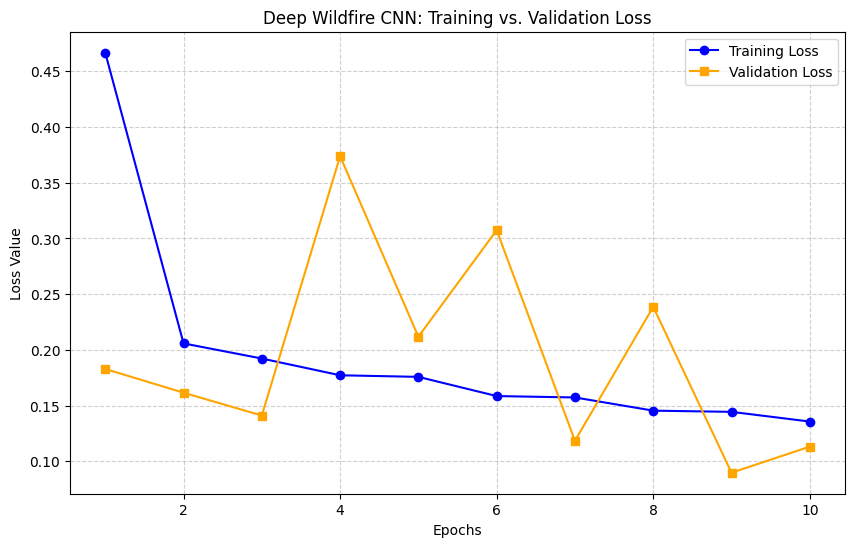

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', color='orange', marker='s')

plt.title('Deep Wildfire CNN: Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [16]:
import pandas as pd
import numpy as np

model.eval()
results = []

# Map index back to filenames
test_filenames = [os.path.basename(f[0]) for f in test_data.imgs]

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        outputs = model(images)

        # Get probabilities using Sigmoid/Softmax
        probs = torch.nn.functional.softmax(outputs, dim=1)
        p_hat = probs[:, 1].cpu().numpy() # Probability of Wildfire

        # Batch start index
        start_idx = i * 32
        batch_filenames = test_filenames[start_idx : start_idx + len(images)]

        for filename, prob in zip(batch_filenames, p_hat):
            # Filenames are format: "long,lat.jpg" (e.g., "-114.0202,50.9532.jpg")
            coords = filename.replace('.jpg', '').split(',')
            try:
                results.append({
                    'longitude': float(coords[0]),
                    'latitude': float(coords[1]),
                    'p_hat': prob,
                    'prediction': 1 if prob > 0.5 else 0
                })
            except ValueError:
                continue

# Convert to DataFrame
df_results = pd.DataFrame(results)
print(df_results.head())

    longitude   latitude     p_hat  prediction
0 -113.917770  50.901087  0.007246           0
1 -113.917820  50.896917  0.015985           0
2 -113.917930  51.091205  0.005849           0
3 -113.918016  50.978447  0.007126           0
4 -113.918155  51.129969  0.007583           0


<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_15639/3577841155.py:15: SyntaxWarning: invalid escape sequence '\h'
  plt.colorbar(sc, label='Probability ($\hat{p}$)')


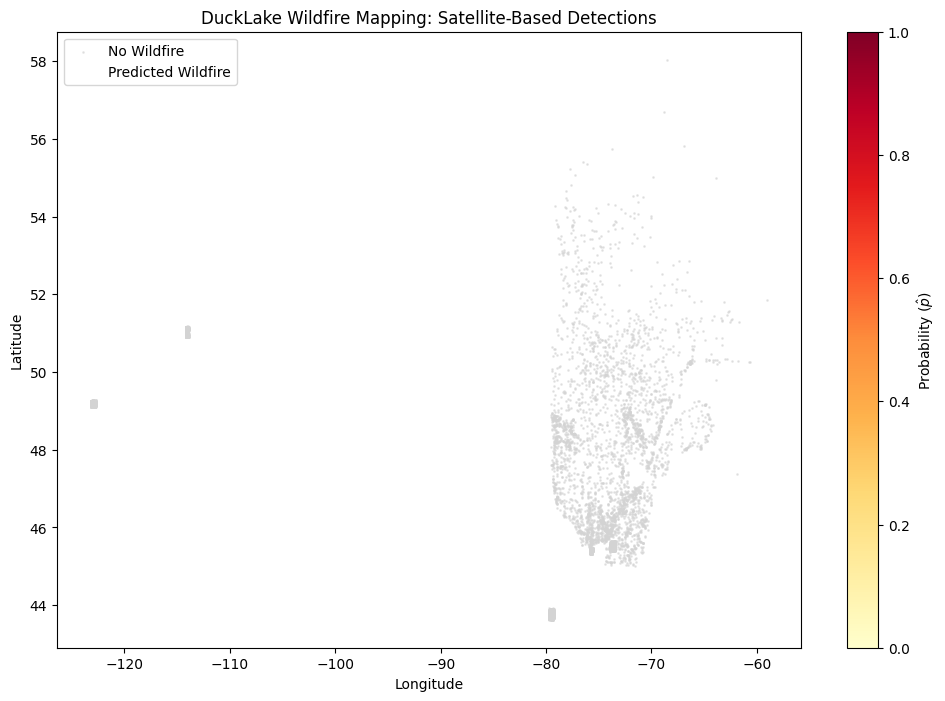

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot "No Wildfire" as small gray dots
no_fire = df_results[df_results['prediction'] == 0]
plt.scatter(no_fire['longitude'], no_fire['latitude'],
            c='lightgrey', s=1, alpha=0.5, label='No Wildfire')

# Plot "Wildfire" predictions with a color gradient based on p_hat
fire = df_results[df_results['prediction'] == 1]
sc = plt.scatter(fire['longitude'], fire['latitude'],
                 c=fire['p_hat'], cmap='YlOrRd', s=10, label='Predicted Wildfire')

plt.colorbar(sc, label='Probability ($\hat{p}$)')
plt.title('DuckLake Wildfire Mapping: Satellite-Based Detections')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()